<font color="#de3023"><h1><b>REMINDER MAKE A COPY OF THIS NOTEBOOK, DO NOT EDIT</b></h1></font>

# Goals
In this colab you will:
* Experiment with how different types of regression models perform.
* Brainstorm and discuss how the government decides which model (or if to use a model) to implement in their policy-making decisions.
* Use evaluation metrics and decision analytics in order to determine how much your model would increase crop yield compared to not using a machine learning model at all in policy decisions.

In [ ]:
#@title ###Setup notebook.
#@title ###Setup notebook.

!gdown --id 1DgOZ56YruuUmHRD7hZNJNM39mlbRGApp # sample metadata
!gdown --id 1R4Nv1SY4zn_Z3wnZuJcCHKI6yVPGGgGZ # bacteria counts lognorm


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error

metadata = pd.read_table('sample_metadata.tsv')
metadata.index = ['farm_%i' % i for i in range(len(metadata))]

bacteria_counts_lognorm = pd.read_csv('bacteria_counts_lognorm.csv', index_col=0)

/usr/local/lib/python3.7/dist-packages/gdown/cli.py:131: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  category=FutureWarning,
Downloading...
From: https://drive.google.com/uc?id=1DgOZ56YruuUmHRD7hZNJNM39mlbRGApp
To: /content/sample_metadata.tsv
100% 64.3k/64.3k [00:00<00:00, 40.8MB/s]
/usr/local/lib/python3.7/dist-packages/gdown/cli.py:131: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  category=FutureWarning,
Downloading...
From: https://drive.google.com/uc?id=1R4Nv1SY4zn_Z3wnZuJcCHKI6yVPGGgGZ
To: /content/bacteria_counts_lognorm.csv
100% 7.44M/7.44M [00:00<00:00, 98.3MB/s]


# Experimenting with Different Models

Recall our machine learning problem: We wish to predict crop yield from bacterial composition of soil. Answer the following:


In [ ]:
#@title **Review: Is this a regression or classification problem, and why?**
answer = "classification" #@param ["regression", "classification"]
reason = ''#@param {type:"string"}



In [ ]:
#@title **Question: What are some other possible models you can use for regression?** Check out the [scikit-learn documentation](https://scikit-learn.org/stable/supervised_learning.html) for clues!
_1_ = '' #@param {type:"string"}
_2_ = '' #@param {type:"string"}

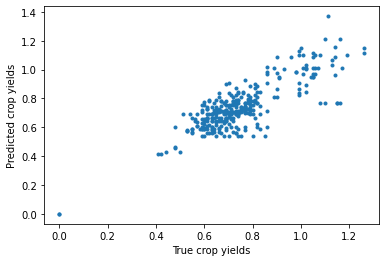

In [ ]:
#@title Decision Tree Regressor Performance
# We helped you define your X and y data here.
X = bacteria_counts_lognorm
y = metadata['crop_yield']

# Split your data into testing and training.
X_train_dtr, X_test_dtr, y_train_dtr, y_test_dtr = train_test_split(X, y)

# Now, initialize your model (just use the default settings for now!)
decision_tree_regressor = DecisionTreeRegressor(max_depth=100, max_leaf_nodes=200)

# Now, initialize your model (just use the default settings for now!)
decision_tree_regressor.fit(X_train_dtr, y_train_dtr)

# Make predictions on your test data. (Don't try to compute accuracy just yet...)
preds_dtr = decision_tree_regressor.predict(X_test_dtr)

# Plot your predictions against the true crop yields of the test data

plt.plot(y_test_dtr, preds_dtr, '.')
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

# Experimenting with Different Models

As you've learned, there are many types of models that you can choose for any given machine learning problem! Let's work as a group to figure out what type of model works the best for predicting crop yield from bacterial soil composition.



Run the cell below to recall how your original ```DecisionTreeRegressor``` performed.

In [ ]:
# We helped you define your X and y data here.
X = bacteria_counts_lognorm
y = metadata['crop_yield']

# Split your data into testing and training.
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Now, initialize your model (just use the default settings for now!)
model = DecisionTreeRegressor(max_depth=100, max_leaf_nodes=200)

# Now, initialize your model (just use the default settings for now!)
model.fit(X_train, y_train)

# Make predictions on your test data. (Don't try to compute accuracy just yet...)
preds = model.predict(X_test)

# Plot your predictions against the true crop yields of the test data
plt.plot(y_test, preds, '.')
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

###**Exericse: Now go ahead and pick your favorite regression model (we have imported  ```LinearRegression```, ```MLPRegressor``` and ```KNNRegression``` for you), with your favorite hyperparameters. Go ahead and train that model, and plot test predictions against true crop yields, similarly to the cell before.**

In [ ]:
# Initialize your model (just use the default settings for now!)
### FILL IN ###

# Train your model.
### FILL IN ###

# Make predictions on your test data. (Don't try to compute accuracy just yet...)
### FILL IN ###

# Plot your predictions against the true crop yields of the test data
### FILL IN ###
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

# Policy Making

<img src = "https://upload.wikimedia.org/wikipedia/commons/e/ee/Korea_President_Park_US_Congress_20130507_03.jpg" width=500/>

In [ ]:
#@title **Exercise: If you were a policy-maker trying to figure out where to allow farming, how would you decide which model to rely on?**
_1_ = '' #@param {type:"string"}
_2_ = '' #@param {type:"string"}
_3_ = '' #@param {type:"string"}


Interestingly, often policy-makers (and people in the medical field) prefer decision trees, linear regression, and other simple models over more sophisticted models such as neural networks. **Discuss: Why do you think that is?**

Skim [this article](https://www.brookings.edu/techstream/the-tensions-between-explainable-ai-and-good-public-policy/).

In [ ]:
#@title **Exercise: According to the article above, what are 3 challenges AI faces when it comes to being implemented in public policy?**
_1_ = '' #@param {type:"string"}
_2_ = '' #@param {type:"string"}
_3_ = '' #@param {type:"string"}


Keep all of this in mind while we explore 2 ways of evaluating machine learning models!

# Evaluating Regression Models


The first method we are going to explore is how to use some simple evaluation metrics to assess which model has better performance.

**Discuss: During the first week of the course, what metrics did you use to measure how well a classifier was performing? Why won't these metrics (like accuracy) work for our machine learning task (predicting crop yield from soil bacteria)?**

There are three popular metrics that we usually report to measure regressor performance. If you think all the way back to the beginning of the course, we talked about a couple of these in the first few days!

### 1. Coefficient of determination ($R^2$).

Since R is the correlation between the test predictions and the true test y-values, $R^2$ is a measure of how well the variabilty in the test predictions are explained by the variability in the true values. You can compute $R2$ using the ```r2_score``` function. Correlation between data points can be described by the image below. Note that you might remember $R^2$ for linear regression. Well $R^2$ can be used to evaluate the performance of any regression model, since regression models are predicting continuous variables.

<img src="https://miro.medium.com/max/700/0*zgSKANTyadZmfhDJ.gif"/>

####**Discuss: Should a good model have a high or low $R^2$?**


####**Exercise: Compute the $R^2$ for your model using the ```r2_score``` function.**

In [ ]:
R2 = r2_score(y_test, preds) ## FILL IN ###
print('R2=', R2)

NameError: ignored

**Discuss: Which model performed the best?***

## **OPTIONAL: Additional Evaluation Metrics**

### 2. Mean Absolute Error (`MAE`)
The mean absolute error is the average error between your test predictions and your true values of y.  We can compute the Mean Absolute Error using the ```sklearn``` ```mean_absolute_error``` function. **Discuss: Should a good model have a big or small MAE?**

####**Exercise: Compute the MAE for your model using the ```mean_absolute_error``` function.**

In [ ]:
MAE = None ## FILL IN ###
print('MAE=', MAE)

### 3. OPTIONAL: Relative Squared Error (RSE)
The relative squared error (RSE) is the error in the model predictions relative to the predictions we would have gotten if we used a very "simple model" (this "simple model" just being the average of all of the test data values). A good model has a RSE close to zero, and a bad model has an RSE close to or higher than 1.

####**Exercise: Fill out the following code to compute the RSE of your model.**

*Hint*: to compute averages, take a look at [this function documentation!](https://numpy.org/doc/stable/reference/generated/numpy.mean.html)

In [ ]:
# Compute RSE using y_test and preds.
def relative_squared_error(true_vals, pred_vals):

  # Compute the total squared error for our predictions.
  total_squared_error = sum((pred_vals-true_vals)**2)

  # Compute the average of true_vals.
  average_of_true_vals = np.average(true_vals) ### FILL IN ###

  # Compute the total squared error if we were using a simple model.
  total_squared_error_simple_predictor  = sum((average_of_true_vals-true_vals)**2)

  # Return the ratio of total squared errors for our model compared to the simple model.
  return (total_squared_error/total_squared_error_simple_predictor)


# Use your newly defined function to compute the relative squared error using y_test and preds.
RSE = relative_squared_error(y_test, preds) ### FILL IN ###
print('RSE=', RSE)

NameError: ignored

### **Discuss: Which model produced the best $R^2$, MAE, and RSE? Did the same model perform the best in all metrics?**

**END OF OPTIONAL SECTION**


---



# Decision Analytics

Ultimately, coefficient of determination, MAE, and RSE are not what we *really* care about. What we really care about is how much a model will improve the world's farming practices.  In our case, we would like to know how much using a particular model will increase crop yield compared to using other models or no models at all.

***Decision analytics*** is a field dedicated to using mathematics, computer simulations, and machine learning in order to quantitatively make decisons. Decision analytics and machine learning often go hand-in-hand!  

Using the results of our machine learning model, we are going to write a small computer simulation to see how much our model will improve crop yield compared to not using a model at all.

<img src = "https://www.environmentalscience.org/wp-content/uploads/2018/09/Env-Law-Scale-300x300.jpg"/>

## Identifying Fields to Farm On

Imagine this scenario: In trying to keep up with the dietary needs of their people, a country's government plans on choosing 10 new plots of land to subsidize for farming. Let's pretend they are using your model (trained on your *training* data) to decide which plots of land to convert to farms (choosing between those in your *test* data).

Before going to the exercise, **discuss: Which 10 farms should your model choose?**

In [ ]:
metadata

,crop_yield,sample_type,country,timestamp
farm_0,0.68,barley soil sample,GAZ:Australia,2011-3-26
farm_1,1.00,barley soil sample,GAZ:Australia,2011-11-22
farm_2,0.87,barley soil sample,GAZ:Australia,2011-6-10
farm_3,0.68,barley soil sample,GAZ:Australia,2011-11-3
farm_4,0.67,barley soil sample,GAZ:Australia,2011-3-26
...,...,...,...,...
farm_1339,0.74,barley soil sample,GAZ:Australia,2011-3-9
farm_1340,0.77,barley soil sample,GAZ:Australia,2011-9-25
farm_1341,0.69,barley soil sample,GAZ:Australia,2011-2-13
farm_1342,0.44,barley soil sample,GAZ:Australia,2011-1-2


#### **Exercise: Find the names of the top 10 farms that your model predicted will have the highest crop yield**

To do this, we're first going to need our predictions. Then, we'll create a new pandas dataframe with the predictions and their corresponding farm numbers. Fill in the code to get the yield predictions in the cell below, then run it to see our new dataframe.

In [ ]:
# Just to practice *again*, fill this in to make crop yield predictions
# on your training data. You can use whatever model you trained most recently.
crop_yield_test_predictions = None ### FILL IN ####

yield_predictions_dataframe = pd.DataFrame(data={'farm':X_test.index, 'crop_yield':crop_yield_test_predictions})
yield_predictions_dataframe.head()

NameError: ignored

Now that we have our predictions dataframe, we can sort it to find the top 10 farms! Fill in the code below to sort  `yield_predictions_dataframe`.

In [ ]:
# Sort your predictions dataframe (in variable called yield_predictions_dataframe) by crop yield, and look at the top 10 farms.
# Hint: You can use .sort_values('crop_yield', ascending=False) on the yield_predictions_dataframe variable.
sorted_dataframe = yield_predictions_dataframe # FILL IN ####

# Take the top 10 farms using .head().
top_farms_dataframe = sorted_dataframe.head(10)
farm_names=top_farms_dataframe['farm']
print("According to our model, the top 10 best plots are:", farm_names.to_list())
top_farms_dataframe

####**Exercise: If the government had gone with this model's suggestions, what would have been the total crop yield of the 10 farms?** Fill in the code below to compute.



In [ ]:
# This extracts the true crop yields from the 10 farms the model suggested.
# crop_yields_top_10_predictions is thus an array of crop yields with length 10.
crop_yields_top_10_predictions = top_farms_dataframe['crop_yield']


# Fill in the line below to compute the total crop yield from all 10 farms combined.
total_crop_yield_using_model = None #### FILL IN ####
print("total crop yield using model suggestions: ", total_crop_yield_using_model)

#### **Exercise: Which of your group member's models led to the highest total crop yield?**

## **OPTIONAL**: Does our model perform better than random chance?

**Discuss: What if the government didn't use our model, and just did a lottery instead? What would total crop yield be then? How would we 'simulate' that?**

<img src ="https://live.staticflickr.com/600/23203939895_7a81a512b8_b.jpg" width=400 />

#### **Exercise: Fill in the code below to 'simulate' the government picking plots to farm on via lottery, rather than using our model.**


In [ ]:
np.random.seed(42) # Change this to pick a different set of randomly chosen

# Fill in the code below to randomly pick 10 farms/crop yields from your test
# data. crop_yields_10_random_picks should then be an array of crop yields with
# length 10.
crop_yields_10_random_picks = np.random.choice(y_test) ## FILL IN  ####

# Fil in the line below to compute the total crop yield from
# all 10 randomly chosen farms combined.
total_crop_yield_using_lottery = None #### FILL IN ####
print("Total crop yield using random picks: ", total_crop_yield_using_lottery)

**Discuss: Which performed better -- your model's farms or the randomly chosen set of farms?**

#### **Exercise: Change the ```random.seed``` in the code above to simulate a different set of randomly chosen farms.  What do you notice?**


Hmmm, we probably want to simulate this process of the government picking  random farms many times in order to understand what range of values we might get for total crop yield.

#### **Exercise: Compute the total crop yield for 100 simulations of the government choosing 10 random fields to farm on.**


In [ ]:
# Fill in the code below to randomly pick 10 farms/crop yields from your test
# data. crop_yields_10_random_picks should then be an array of crop yields with
# length 10.
total_crop_yield_using_lottery_list = np.array([])
for simulation in range(100): # Let's do 100 iterations.

  crop_yields_10_random_picks = np.random.choice(y_test) ## FILL IN  ###
  total_crop_yield_using_lottery = None #### FILL IN ###

  # Fill in the value you want to append to your list of total crop yields.
  total_crop_yield_using_lottery_list = np.append(total_crop_yield_using_lottery_list, None) ### FILL IN ###

print('lottery crop yields: ', total_crop_yield_using_lottery_list)

#### **Exercise: What would be the average crop yield if the government chose farms based on lottery?**


In [ ]:
# Fill in the code below to randomly pick 10 farms/crop yields from your test
# data. crop_yields_10_random_picks should then be an array of crop yields with
# length 10.
avg_total_crop_yield_from_lottery = None #### Fill out the numpy function that computes average!
print("average crop yield using lottery system:", avg_total_crop_yield_from_lottery)

Run the code below to show a histogram of crop yields using a lottery system compared to crop yields using your model.


In [ ]:
plt.hist(total_crop_yield_using_lottery_list)
plt.vlines(total_crop_yield_using_model, ymin=0, ymax=30, color='r', linestyle='dashed')
plt.xlabel('Total crop yield')
plt.ylabel('Frequency')
plt.title('Total Crop Yield if picked randomly')
print('Dotted line represents total crop yield if using model to select farms.')

**END OF OPTIONAL SECTION**


---



## **Wrapping up: Write a 3-sentence memo to your legislator.**


**Discuss: Based on all of the metrics so far, do you think the government should implement your model into sustainable farming policy?**

<img src = "https://cdn.pixabay.com/photo/2016/02/19/10/12/writing-1209121_1280.jpg" width=300 />


Write a short memo to your legislator/government, briefly explaining to them why (or why not!) they should consider using your machine learning model to select areas to farm rather than selecting areas by lottery or random chance.  Note: Your congressperson may not have ever taken a machine learning course!

P.S. For more information on how to how to communicate to legislators, take a look at this [public policy toolkit](https://www.aafcs.org/pptoolkit/communicate-with-congress-home). Although the tips seem aimed at writing to the U.S. congress, the same advice applies for writing to any level of government in any country in the world!



In [ ]:
#@title Dear legislator, { form-width: "100%" }
_ = "" #@param {type:"string"}
_ = ''